# FinTrustX — Explainable AI for Credit Risk
## Notebook 05: Model Evaluation & Champion Selection

**Objective:**
Perform standardized, comprehensive evaluation of all persisted models on the held-out test dataset without retraining, hyperparameter tuning, or data leakage.

**Key Evaluation Principles:**
- **Class Imbalance:** Credit risk default datasets exhibit severe class imbalance (non-defaults >> defaults). While Accuracy can be misleading, **ROC AUC** and **Average Precision (PR AUC)** evaluate discriminative capability across all decision thresholds.
- **Model Agnostic:** Seamlessly evaluates Scikit-Learn, XGBoost, CatBoost, and TensorFlow/Keras architectures through a unified prediction interface.
- **Business Alignment:** Translates probabilistic risk scores into concrete lending outcomes (Defaults Captured, False Alarms, Capital Protection).

> **Disclaimer:** Explanations and performance metrics describe model associations on historical test data; they are decision-support tools and do not, by themselves, constitute automated credit approvals or denials.

### 1. Environment & Dependency Setup
Verifies the runtime environment and libraries (NumPy, Pandas, Scikit-Learn, TensorFlow, XGBoost, CatBoost, Optuna).

In [1]:
import sys
import os
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Colab / Environment verification
print("=" * 60)
print("ENVIRONMENT & DEPENDENCY VERIFICATION")
print("=" * 60)
print(f"Python version : {sys.version.split()[0]}")

for pkg, name in [
    ("numpy", "NumPy"),
    ("pandas", "Pandas"),
    ("sklearn", "scikit-learn"),
    ("matplotlib", "Matplotlib"),
    ("joblib", "Joblib"),
    ("tensorflow", "TensorFlow"),
    ("xgboost", "XGBoost"),
    ("catboost", "CatBoost"),
    ("optuna", "Optuna"),
]:
    try:
        mod = __import__(pkg)
        ver = getattr(mod, "__version__", "installed")
        print(f"✅ {name:<15} : {ver}")
    except ImportError:
        print(f"⚠️ {name:<15} : Not installed (optional/gracefully handled)")
print("=" * 60)

ENVIRONMENT & DEPENDENCY VERIFICATION
Python version : 3.13.2
✅ NumPy           : 2.4.6
✅ Pandas          : 3.0.5
✅ scikit-learn    : 1.9.0
✅ Matplotlib      : 3.11.1
✅ Joblib          : 1.5.3
✅ TensorFlow      : 2.21.0
✅ XGBoost         : 3.3.0
✅ CatBoost        : 1.2.10
✅ Optuna          : 4.9.0


### 2. Project Root Detection
Dynamically detects the project root folder searching upwards from the notebook directory without hardcoding local paths.

In [2]:
def find_project_root(anchor_dirs=("src", "data", "models"), max_upward=4) -> Path:
    """Dynamically locate the project root by searching upward from cwd or checking subfolder."""
    current = Path.cwd().resolve()
    if (current / "Credit-risk-ai" / "src").is_dir():
        return (current / "Credit-risk-ai").resolve()
    for _ in range(max_upward):
        if all((current / marker).exists() for marker in anchor_dirs):
            return current
        if current.parent == current:
            break
        current = current.parent
    
    if (Path.cwd() / "src").exists():
        return Path.cwd().resolve()
    if (Path.cwd().parent / "src").exists():
        return Path.cwd().parent.resolve()
        
    return Path.cwd().resolve()
    if (Path.cwd().parent / "src").exists():
        return Path.cwd().parent.resolve()
        
    return Path.cwd().resolve()

PROJECT_ROOT = find_project_root()
print(f"📍 Project Root: {PROJECT_ROOT}")

# Add to sys.path if not already present
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
    print(f"✅ Added {PROJECT_ROOT} to sys.path")

# Verify essential directory layout
for folder in ["data", "models", "reports", "src"]:
    target = PROJECT_ROOT / folder
    status = "✅ Found" if target.exists() else "❌ Missing"
    print(f"  {status}: {folder}/ ({target})")


📍 Project Root: D:\Projects\Credit-risk-ai
✅ Added D:\Projects\Credit-risk-ai to sys.path
  ✅ Found: data/ (D:\Projects\Credit-risk-ai\data)
  ✅ Found: models/ (D:\Projects\Credit-risk-ai\models)
  ✅ Found: reports/ (D:\Projects\Credit-risk-ai\reports)
  ✅ Found: src/ (D:\Projects\Credit-risk-ai\src)


### 3. Configuration Verification
Imports project configurations (`MODEL_NAMES`, `SCORING`, `REPORT_DIR`, `DEEP_LEARNING_TRAINING`) and evaluation utilities.

In [3]:
try:
    from src.config import (
        MODEL_DIR,
        REPORT_DIR,
        MODEL_NAMES,
        SCORING,
        DEEP_LEARNING_TRAINING,
        EVALUATION_REPORTS,
    )
    print("✅ Successfully imported project settings from src.config")
except ImportError as e:
    print(f"⚠️ src.config import warning: {e}. Using resilient defaults.")
    MODEL_DIR = PROJECT_ROOT / "models"
    REPORT_DIR = PROJECT_ROOT / "reports"
    SCORING = "roc_auc"
    MODEL_NAMES = {
        "decision_tree": "decision_tree.joblib",
        "random_forest": "random_forest.joblib",
        "xgboost": "xgboost.joblib",
        "catboost": "catboost.joblib",
        "neural_network": "neural_network.keras"
    }
    DEEP_LEARNING_TRAINING = {"target_column": "TARGET", "test_filename": "processed_test.parquet"}
    EVALUATION_REPORTS = {"comparison_filename": "model_comparison.csv"}

try:
    from src.evaluate import (
        evaluate_model,
        business_metrics,
        compare_models,
        save_results,
        EvaluationEngine,
    )
    print("✅ Successfully imported evaluation utilities from src.evaluate")
except ImportError as e:
    print(f"❌ Error importing src.evaluate: {e}")

print(f"\nConfigured Primary Selection Metric: {SCORING.upper()}")
print(f"Configured Models to inspect: {list(MODEL_NAMES.keys())}")

✅ Successfully imported project settings from src.config
✅ Successfully imported evaluation utilities from src.evaluate

Configured Primary Selection Metric: ROC_AUC
Configured Models to inspect: ['decision_tree', 'random_forest', 'xgboost', 'catboost', 'neural_network']


### 4. Load Processed Test Data
Discovers and loads the held-out processed test dataset without assuming static filenames or formats.

In [4]:
import pandas as pd
import numpy as np

def discover_test_dataset(project_root: Path) -> Path | None:
    """Inspect data directories and locate the processed test dataset."""
    data_dir = project_root / "data"
    candidate_locations = [
        data_dir / "processed",
        data_dir,
    ]
    
    preferred_name = DEEP_LEARNING_TRAINING.get("test_filename", "processed_test.parquet")
    
    # Priority 1: Configured test file
    for loc in candidate_locations:
        if (loc / preferred_name).exists():
            return loc / preferred_name
            
    # Priority 2: Any parquet or csv with 'test' in the filename
    for loc in candidate_locations:
        if loc.exists():
            for f in loc.iterdir():
                if f.is_file() and "test" in f.name.lower() and f.suffix in [".parquet", ".csv"]:
                    return f
    return None

test_file_path = discover_test_dataset(PROJECT_ROOT)

if test_file_path is None:
    raise FileNotFoundError(
        f"❌ No test dataset found under {PROJECT_ROOT / 'data'}. "
        "Please ensure data preprocessing has completed."
    )

print(f"📊 Discovered Test Dataset: {test_file_path.name} (Format: {test_file_path.suffix})")
print(f"   Full Path: {test_file_path}")
print(f"   Size: {test_file_path.stat().st_size / (1024*1024):.2f} MB")

# Load dataframe
if test_file_path.suffix == ".parquet":
    test_df = pd.read_parquet(test_file_path)
elif test_file_path.suffix == ".csv":
    test_df = pd.read_csv(test_file_path)
else:
    raise ValueError(f"Unsupported file format: {test_file_path.suffix}")

# Separate features and target
target_col = DEEP_LEARNING_TRAINING.get("target_column", "TARGET")
if target_col not in test_df.columns:
    if "TARGET" in test_df.columns:
        target_col = "TARGET"
    elif "target" in test_df.columns:
        target_col = "target"
    else:
        raise KeyError(f"Target column '{target_col}' not found in dataset columns.")

X_test = test_df.drop(columns=[target_col])
y_test = test_df[target_col].astype(int)

print(f"\n✅ Test data loaded successfully: X_test {X_test.shape}, y_test {y_test.shape}")

📊 Discovered Test Dataset: processed_test.parquet (Format: .parquet)
   Full Path: D:\Projects\Credit-risk-ai\data\processed_test.parquet
   Size: 6.77 MB

✅ Test data loaded successfully: X_test (61503, 245), y_test (61503,)


### 5. Validate Test Data Integrity & Class Distribution
Performs sanity checks for missing values, infinite values, label encoding, and class imbalance.

In [5]:
print("=" * 60)
print("DATASET INTEGRITY & CLASS DISTRIBUTION VALIDATION")
print("=" * 60)

# Check lengths
assert len(X_test) == len(y_test), f"Length mismatch: {len(X_test)} vs {len(y_test)}"

# Binary check
unique_targets = set(np.unique(y_test))
assert unique_targets.issubset({0, 1}), f"Non-binary target detected: {unique_targets}"

# Missing values check
missing_features = X_test.isnull().sum().sum()
missing_target = y_test.isnull().sum()
print(f"Missing Values in Features : {missing_features}")
print(f"Missing Values in Target   : {missing_target}")

# Inf values check (numeric columns)
numeric_cols = X_test.select_dtypes(include=[np.number]).columns
inf_count = np.isinf(X_test[numeric_cols].values).sum()
print(f"Infinite Values in Numeric : {inf_count}")

# Class distribution
counts = y_test.value_counts().to_dict()
percentages = (y_test.value_counts(normalize=True) * 100).to_dict()
print(f"\nTarget Distribution (TARGET = 1 denotes Default):")
print(f"  Class 0 (Non-Default) : {counts.get(0, 0):>6} rows ({percentages.get(0, 0.0):.2f}%)")
print(f"  Class 1 (Default)     : {counts.get(1, 0):>6} rows ({percentages.get(1, 0.0):.2f}%)")
imbalance_ratio = counts.get(0, 1) / max(counts.get(1, 1), 1)
print(f"  Imbalance Ratio       : ~{imbalance_ratio:.1f} : 1")
print("=" * 60)

DATASET INTEGRITY & CLASS DISTRIBUTION VALIDATION
Missing Values in Features : 0
Missing Values in Target   : 0
Infinite Values in Numeric : 0

Target Distribution (TARGET = 1 denotes Default):
  Class 0 (Non-Default) :  56538 rows (91.93%)
  Class 1 (Default)     :   4965 rows (8.07%)
  Imbalance Ratio       : ~11.4 : 1


### 6. Load Trained Models
Discovers and loads all available model artifacts (.joblib, .keras, .pkl), reporting missing models gracefully.

In [6]:
import joblib

available_models = {}
unavailable_models = {}

print("=" * 60)
print("MODEL ARTIFACT DISCOVERY & LOADING")
print("=" * 60)

for model_key, filename in MODEL_NAMES.items():
    model_path = MODEL_DIR / filename
    
    if not model_path.exists():
        model_path = PROJECT_ROOT / filename
        
    if not model_path.exists():
        unavailable_models[model_key] = f"Artifact not found: {filename}"
        print(f"❌ {model_key:<16} : Not Found at {model_path.name}")
        continue
        
    try:
        if filename.endswith(".keras") or filename.endswith(".h5"):
            import tensorflow as tf
            loaded_model = tf.keras.models.load_model(model_path)
            available_models[model_key] = loaded_model
            print(f"✅ {model_key:<16} : Loaded successfully (Keras model from {filename})")
        else:
            loaded_model = joblib.load(model_path)
            available_models[model_key] = loaded_model
            print(f"✅ {model_key:<16} : Loaded successfully (Scikit-Learn/Joblib from {filename})")
    except Exception as err:
        unavailable_models[model_key] = f"Error during loading: {err}"
        print(f"⚠️ {model_key:<16} : Failed to load ({err})")

print("-" * 60)
print(f"Total Models Available for Evaluation: {len(available_models)} / {len(MODEL_NAMES)}")
if unavailable_models:
    print(f"Unavailable Models: {list(unavailable_models.keys())}")
print("=" * 60)

MODEL ARTIFACT DISCOVERY & LOADING
✅ decision_tree    : Loaded successfully (Scikit-Learn/Joblib from decision_tree.joblib)
✅ random_forest    : Loaded successfully (Scikit-Learn/Joblib from random_forest.joblib)
❌ xgboost          : Not Found at xgboost.joblib
❌ catboost         : Not Found at catboost.joblib
❌ neural_network   : Not Found at neural_network.keras
------------------------------------------------------------
Total Models Available for Evaluation: 2 / 5
Unavailable Models: ['xgboost', 'catboost', 'neural_network']


### 7. Common Model Interface Helpers
Defines internal helper functions to extract uniform 1D positive class probabilities and thresholded binary predictions across all model frameworks.

In [7]:
def get_positive_class_probability(model, X) -> np.ndarray:
    """
    Extract 1D positive class probabilities (P(TARGET=1)) from any supported model.
    Handles Scikit-Learn, XGBoost, CatBoost, Keras, and custom BaseModel wrappers.
    """
    if hasattr(model, "predict_proba"):
        raw = model.predict_proba(X)
    elif hasattr(model, "predict"):
        is_keras = "keras" in type(model).__module__.lower() or "tensorflow" in type(model).__module__.lower()
        raw = model.predict(X, verbose=0) if is_keras else model.predict(X)
    else:
        raise TypeError(f"Model {type(model)} has neither predict_proba nor predict method.")
        
    arr = np.asarray(raw)
    
    if arr.ndim == 1:
        prob = arr
    elif arr.ndim == 2 and arr.shape[1] == 1:
        prob = arr[:, 0]
    elif arr.ndim == 2 and arr.shape[1] >= 2:
        prob = arr[:, 1]
    else:
        raise ValueError(f"Unexpected prediction output shape: {arr.shape}")
        
    prob = prob.astype(float).reshape(-1)
    
    if np.any(np.isnan(prob)) or np.any(np.isinf(prob)):
        raise ValueError("Extracted probabilities contain NaN or Infinite values.")
        
    if len(prob) != len(X):
        raise ValueError(f"Probability length {len(prob)} does not match sample count {len(X)}.")
        
    return prob

def get_binary_predictions(model, X, threshold: float = 0.5) -> np.ndarray:
    """Convert positive class probabilities into binary predictions (0 or 1) using a threshold."""
    probs = get_positive_class_probability(model, X)
    return (probs >= threshold).astype(int)

# Quick interface smoke-test on first 5 samples
print("Validating model interface consistency:")
for name, m in available_models.items():
    sample_p = get_positive_class_probability(m, X_test.iloc[:5])
    sample_y = get_binary_predictions(m, X_test.iloc[:5], threshold=0.5)
    print(f"  ✅ {name:<16}: Sample Probabilities = {np.round(sample_p, 4)}, Classes = {sample_y}")

Validating model interface consistency:
  ✅ decision_tree   : Sample Probabilities = [0.4419 0.1749 0.6214 0.4869 0.6463], Classes = [0 0 1 0 1]
  ✅ random_forest   : Sample Probabilities = [0.2993 0.2228 0.4775 0.3567 0.46  ], Classes = [0 0 0 0 0]


### 8. Standardized Model Evaluation
Evaluates all available models using `src.evaluate.evaluate_model()`, computing discrimination, ranking, and calibration metrics.

In [8]:
evaluation_results = {}

if not available_models:
    print("❌ No models available to evaluate.")
else:
    for name, model in available_models.items():
        print(f"Evaluating {name} on {len(X_test)} test samples...")
        try:
            metrics = evaluate_model(model, X_test, y_test, threshold=0.5, plot=False)
            evaluation_results[name] = metrics
            print(f"  ✅ {name} -> ROC AUC: {metrics.get('ROC AUC', 0):.4f} | PR AUC: {metrics.get('Average Precision', 0):.4f} | F1: {metrics.get('F1 Score', 0):.4f}")
        except Exception as e:
            print(f"  ❌ Error evaluating {name} via evaluate_model: {e}")
            try:
                from sklearn.metrics import (
                    roc_auc_score, average_precision_score, accuracy_score,
                    precision_score, recall_score, f1_score, balanced_accuracy_score
                )
                probs = get_positive_class_probability(model, X_test)
                preds = (probs >= 0.5).astype(int)
                fallback_metrics = {
                    "Accuracy": float(accuracy_score(y_test, preds)),
                    "Precision": float(precision_score(y_test, preds, zero_division=0)),
                    "Recall": float(recall_score(y_test, preds, zero_division=0)),
                    "F1 Score": float(f1_score(y_test, preds, zero_division=0)),
                    "ROC AUC": float(roc_auc_score(y_test, probs)),
                    "Average Precision": float(average_precision_score(y_test, probs)),
                    "Balanced Accuracy": float(balanced_accuracy_score(y_test, preds)),
                }
                evaluation_results[name] = fallback_metrics
                print(f"  ✅ {name} (via fallback calculation) -> ROC AUC: {fallback_metrics['ROC AUC']:.4f}")
            except Exception as fb_err:
                print(f"  ❌ Fallback calculation also failed for {name}: {fb_err}")

Evaluating decision_tree on 61503 test samples...
  ✅ decision_tree -> ROC AUC: 0.6282 | PR AUC: 0.1211 | F1: 0.1901
Evaluating random_forest on 61503 test samples...
  ✅ random_forest -> ROC AUC: 0.7382 | PR AUC: 0.2139 | F1: 0.2786


### 9. Model Performance Comparison Table
Compiles all metric scores into a structured comparison DataFrame sorted by the configured primary metric.

In [9]:
metric_cols = [
    "ROC AUC",
    "Average Precision",
    "F1 Score",
    "Recall",
    "Precision",
    "Balanced Accuracy",
    "Accuracy",
    "Matthews Corrcoef",
    "Cohen Kappa",
    "Log Loss",
    "Brier Score Loss",
]

if evaluation_results:
    comparison_df = pd.DataFrame.from_dict(evaluation_results, orient="index")
    comparison_df.index.name = "Model"
    
    present_cols = [col for col in metric_cols if col in comparison_df.columns]
    comparison_df = comparison_df[present_cols]
    
    primary_metric = "ROC AUC"
    if SCORING and SCORING.lower() in ["average_precision", "pr_auc"]:
        primary_metric = "Average Precision"
    elif SCORING and SCORING.lower() in ["roc_auc", "auc"]:
        primary_metric = "ROC AUC"
        
    if primary_metric in comparison_df.columns:
        comparison_df = comparison_df.sort_values(by=primary_metric, ascending=False)
        
    print(f"=== MODEL PERFORMANCE COMPARISON (Sorted by {primary_metric}) ===")
    display(comparison_df.round(4))
else:
    print("No evaluation results available.")
    comparison_df = pd.DataFrame()

=== MODEL PERFORMANCE COMPARISON (Sorted by ROC AUC) ===


,ROC AUC,Average Precision,F1 Score,Recall,Precision,Balanced Accuracy,Accuracy,Matthews Corrcoef,Cohen Kappa,Log Loss,Brier Score Loss
Model,,,,,,,,,,,
random_forest,0.7382,0.2139,0.2786,0.3186,0.2475,0.6168,0.8668,0.2085,0.2065,0.4226,0.1270
decision_tree,0.6282,0.1211,0.1901,0.6828,0.1104,0.5999,0.5304,0.1088,0.0594,0.7889,0.2323


### 10. Credit Risk Business Impact Metrics
Translates raw machine learning predictions into business metrics (Defaults Captured, False Alarms, Capital Protection) using `src.evaluate.business_metrics()`.

In [10]:
business_results = {}

if available_models:
    for name, model in available_models.items():
        try:
            preds = get_binary_predictions(model, X_test, threshold=0.5)
            bm = business_metrics(y_test, preds)
            business_results[name] = bm
        except Exception as e:
            print(f"❌ Error calculating business metrics for {name}: {e}")

if business_results:
    business_df = pd.DataFrame.from_dict(business_results, orient="index")
    business_df.index.name = "Model"
    
    biz_cols_order = [
        "True Defaults Captured",
        "False Defaults Flagged",
        "Good Customers Cleared",
        "Defaults Missed",
        "Default Capture Rate",
        "Approval Precision",
    ]
    present_biz_cols = [c for c in biz_cols_order if c in business_df.columns]
    for c in business_df.columns:
        if c not in present_biz_cols:
            present_biz_cols.append(c)
            
    business_df = business_df[present_biz_cols]
    print("=== CREDIT RISK BUSINESS IMPACT METRICS (Threshold = 0.50) ===")
    display(business_df)
else:
    business_df = pd.DataFrame()

=== CREDIT RISK BUSINESS IMPACT METRICS (Threshold = 0.50) ===


,True Defaults Captured,False Defaults Flagged,Good Customers Cleared,Defaults Missed,Default Capture Rate,Approval Precision,True Approvals,False Approvals,True Rejections,False Rejections,Default Capture
Model,,,,,,,,,,,
decision_tree,3390,27309,29229,1575,0.682779,0.110427,3390,27309,29229,1575,0.682779
random_forest,1582,4809,51729,3383,0.318630,0.247536,1582,4809,51729,3383,0.318630


### 11. Multi-Dimensional Model Ranking
Ranks all evaluated models across distinct performance dimensions.

In [11]:
if not comparison_df.empty:
    ranking_records = []
    
    for metric in ["ROC AUC", "Average Precision", "Recall", "F1 Score", "Balanced Accuracy"]:
        if metric in comparison_df.columns:
            top_model = comparison_df[metric].idxmax()
            top_score = comparison_df.loc[top_model, metric]
            ranking_records.append({
                "Metric Dimension": metric,
                "Best Model": top_model,
                "Score": f"{top_score:.4f}",
                "Significance": (
                    "Global discrimination ranking" if metric == "ROC AUC" else
                    "Minority-class precision-recall tradeoff" if metric == "Average Precision" else
                    "Default identification capability (Avoid bad loans)" if metric == "Recall" else
                    "Harmonic balance between default capture and false alarms" if metric == "F1 Score" else
                    "Balanced accuracy across both classes"
                )
            })
            
    ranking_df = pd.DataFrame(ranking_records)
    print("=== MODEL BENCHMARK RANKINGS ===")
    display(ranking_df)
else:
    ranking_df = pd.DataFrame()

=== MODEL BENCHMARK RANKINGS ===


,Metric Dimension,Best Model,Score,Significance
0,ROC AUC,random_forest,0.7382,Global discrimination ranking
1,Average Precision,random_forest,0.2139,Minority-class precision-recall tradeoff
2,Recall,decision_tree,0.6828,Default identification capability (Avoid bad l...
3,F1 Score,random_forest,0.2786,Harmonic balance between default capture and f...
4,Balanced Accuracy,random_forest,0.6168,Balanced accuracy across both classes


### 12. Combined ROC Curve Comparison
Renders combined Receiver Operating Characteristic (ROC) curves across all models using probability predictions.

Could not plot ROC for decision_tree: RocCurveDisplay.from_predictions() got an unexpected keyword argument 'linewidth'
Could not plot ROC for random_forest: RocCurveDisplay.from_predictions() got an unexpected keyword argument 'linewidth'


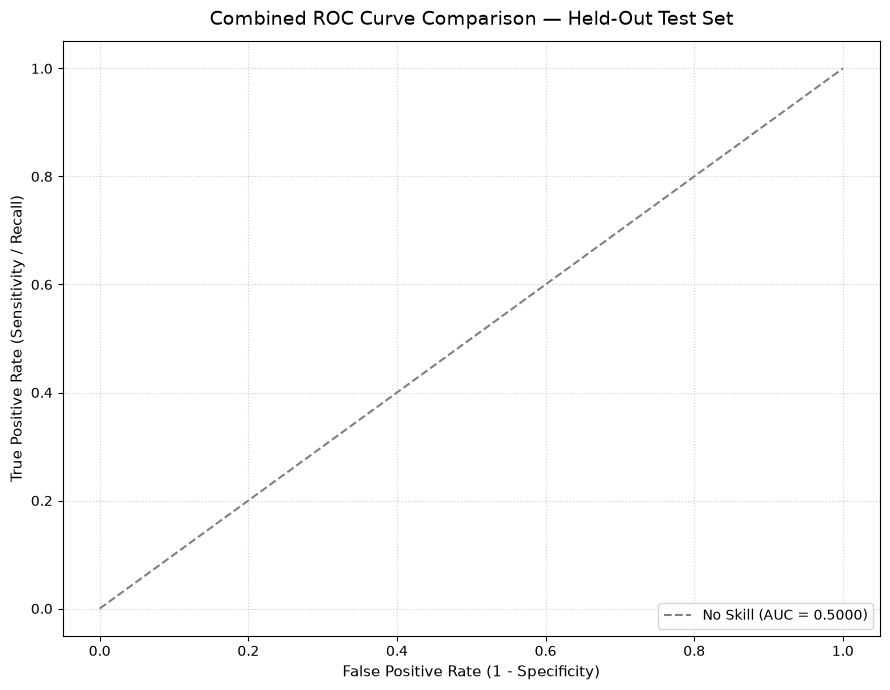

In [12]:
import matplotlib.pyplot as plt
from sklearn.metrics import RocCurveDisplay, roc_auc_score

if available_models:
    fig, ax = plt.subplots(figsize=(9, 7))
    
    for name, model in available_models.items():
        try:
            probs = get_positive_class_probability(model, X_test)
            auc_val = roc_auc_score(y_test, probs)
            RocCurveDisplay.from_predictions(
                y_test,
                probs,
                name=f"{name} (AUC = {auc_val:.4f})",
                ax=ax,
                linewidth=2,
            )
        except Exception as e:
            print(f"Could not plot ROC for {name}: {e}")
            
    ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="No Skill (AUC = 0.5000)")
    ax.set_title("Combined ROC Curve Comparison — Held-Out Test Set", fontsize=14, pad=12)
    ax.set_xlabel("False Positive Rate (1 - Specificity)", fontsize=11)
    ax.set_ylabel("True Positive Rate (Sensitivity / Recall)", fontsize=11)
    ax.grid(True, linestyle=":", alpha=0.6)
    ax.legend(loc="lower right", fontsize=10)
    plt.tight_layout()
    plt.show()
else:
    print("No models available for ROC plotting.")

### 13. Combined Precision-Recall Curve Comparison
Essential for imbalanced data, evaluating Precision vs Recall across thresholds against the positive class prevalence baseline.

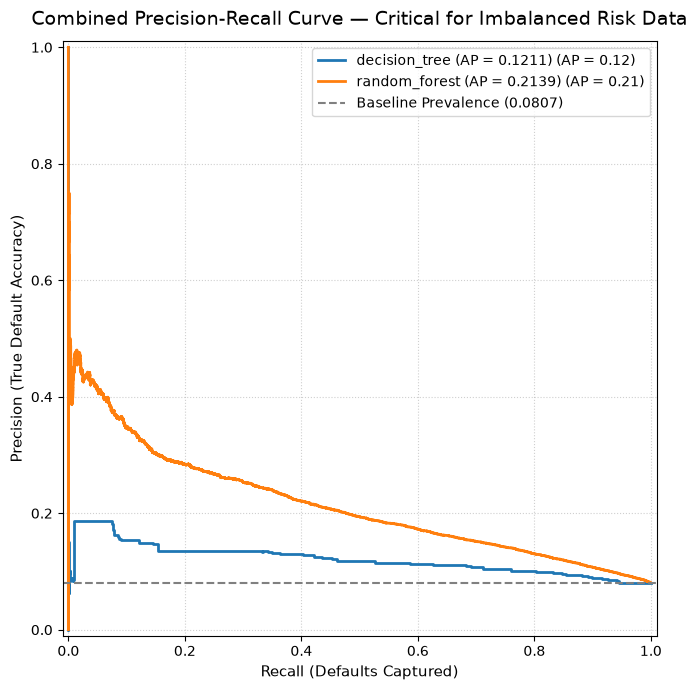

In [13]:
from sklearn.metrics import PrecisionRecallDisplay, average_precision_score

if available_models:
    fig, ax = plt.subplots(figsize=(9, 7))
    prevalence = float(y_test.mean())
    
    for name, model in available_models.items():
        try:
            probs = get_positive_class_probability(model, X_test)
            ap_val = average_precision_score(y_test, probs)
            PrecisionRecallDisplay.from_predictions(
                y_test,
                probs,
                name=f"{name} (AP = {ap_val:.4f})",
                ax=ax,
                linewidth=2,
            )
        except Exception as e:
            print(f"Could not plot PR curve for {name}: {e}")
            
    ax.axhline(prevalence, linestyle="--", color="gray", label=f"Baseline Prevalence ({prevalence:.4f})")
    ax.set_title("Combined Precision-Recall Curve — Critical for Imbalanced Risk Data", fontsize=14, pad=12)
    ax.set_xlabel("Recall (Defaults Captured)", fontsize=11)
    ax.set_ylabel("Precision (True Default Accuracy)", fontsize=11)
    ax.grid(True, linestyle=":", alpha=0.6)
    ax.legend(loc="upper right", fontsize=10)
    plt.tight_layout()
    plt.show()
else:
    print("No models available for PR curve plotting.")

### 14. Confusion Matrices Grid
Visualizes True Positives, False Positives, True Negatives, and False Negatives across all evaluated models.

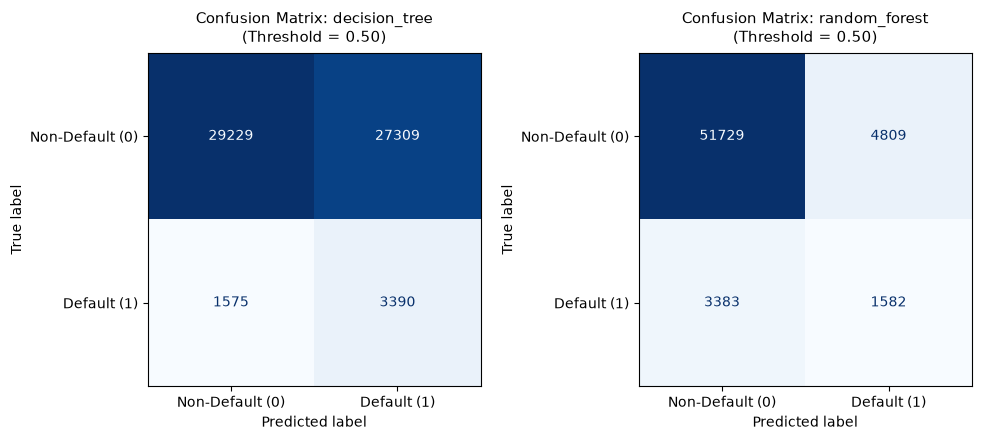

In [14]:
from sklearn.metrics import ConfusionMatrixDisplay

if available_models:
    n_models = len(available_models)
    n_cols = min(3, n_models)
    n_rows = (n_models + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4.5 * n_rows), squeeze=False)
    
    for idx, (name, model) in enumerate(available_models.items()):
        row = idx // n_cols
        col = idx % n_cols
        ax = axes[row][col]
        
        try:
            preds = get_binary_predictions(model, X_test, threshold=0.5)
            ConfusionMatrixDisplay.from_predictions(
                y_test,
                preds,
                display_labels=["Non-Default (0)", "Default (1)"],
                cmap="Blues",
                colorbar=False,
                ax=ax,
            )
            ax.set_title(f"Confusion Matrix: {name}\n(Threshold = 0.50)", fontsize=11, pad=8)
            ax.grid(False)
        except Exception as e:
            ax.set_title(f"{name} (Error)")
            ax.text(0.5, 0.5, f"Plotting failed:\n{e}", ha="center", va="center")
            
    for idx in range(n_models, n_rows * n_cols):
        row = idx // n_cols
        col = idx % n_cols
        axes[row][col].set_visible(False)
        
    plt.tight_layout()
    plt.show()

### 15. Decision Threshold Analysis & Trade-off Optimization
Sweeps decision thresholds from 0.10 to 0.90 on the champion model to evaluate operational risk tradeoffs.

Performing Decision Threshold Sweep on Champion: 'random_forest'


,Precision,Recall (Capture),F1 Score,True Defaults Captured,False Defaults Flagged,Defaults Missed
Threshold,,,,,,
0.1,0.0812,0.9986,0.1502,4958,56091,7
0.2,0.0978,0.9404,0.1772,4669,43061,296
0.3,0.1363,0.7774,0.2319,3860,24459,1105
0.4,0.1857,0.5380,0.2761,2671,11715,2294
0.5,0.2475,0.3186,0.2786,1582,4809,3383
0.6,0.3045,0.1446,0.1961,718,1640,4247
0.7,0.4192,0.0465,0.0838,231,320,4734
0.8,0.4400,0.0022,0.0044,11,14,4954
0.9,0.0000,0.0000,0.0000,0,0,4965


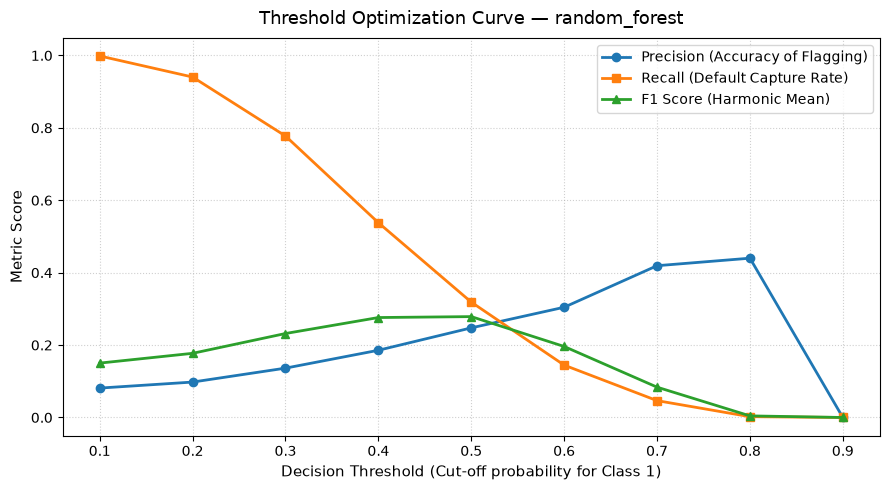

In [15]:
from sklearn.metrics import precision_score, recall_score, f1_score

threshold_df = pd.DataFrame()

if not comparison_df.empty:
    champion_name = comparison_df.index[0]
    champion_model = available_models[champion_name]
    
    print(f"Performing Decision Threshold Sweep on Champion: '{champion_name}'")
    
    thresholds = [0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80, 0.90]
    sweep_records = []
    
    probs = get_positive_class_probability(champion_model, X_test)
    
    for t in thresholds:
        preds = (probs >= t).astype(int)
        
        prec = precision_score(y_test, preds, zero_division=0)
        rec = recall_score(y_test, preds, zero_division=0)
        f1 = f1_score(y_test, preds, zero_division=0)
        
        bm = business_metrics(y_test, preds)
        
        sweep_records.append({
            "Threshold": t,
            "Precision": prec,
            "Recall (Capture)": rec,
            "F1 Score": f1,
            "True Defaults Captured": bm.get("True Defaults Captured", bm.get("True Approvals", 0)),
            "False Defaults Flagged": bm.get("False Defaults Flagged", bm.get("False Approvals", 0)),
            "Defaults Missed": bm.get("Defaults Missed", bm.get("False Rejections", 0)),
        })
        
    threshold_df = pd.DataFrame(sweep_records).set_index("Threshold")
    display(threshold_df.round(4))
    
    # Plot Threshold Curves
    fig, ax = plt.subplots(figsize=(9, 5))
    ax.plot(threshold_df.index, threshold_df["Precision"], marker="o", label="Precision (Accuracy of Flagging)", linewidth=2)
    ax.plot(threshold_df.index, threshold_df["Recall (Capture)"], marker="s", label="Recall (Default Capture Rate)", linewidth=2)
    ax.plot(threshold_df.index, threshold_df["F1 Score"], marker="^", label="F1 Score (Harmonic Mean)", linewidth=2)
    
    ax.set_title(f"Threshold Optimization Curve — {champion_name}", fontsize=13, pad=10)
    ax.set_xlabel("Decision Threshold (Cut-off probability for Class 1)", fontsize=11)
    ax.set_ylabel("Metric Score", fontsize=11)
    ax.grid(True, linestyle=":", alpha=0.6)
    ax.legend(loc="best", fontsize=10)
    plt.tight_layout()
    plt.show()

### 16. Final Champion Model Selection
Declares the champion model based on the project's primary metric and presents governance guidelines.

In [16]:
if not comparison_df.empty:
    champion_name = comparison_df.index[0]
    champion_score = comparison_df.loc[champion_name, primary_metric]
    champion_path = MODEL_DIR / MODEL_NAMES.get(champion_name, f"{champion_name}.joblib")
    
    print("=" * 65)
    print("👑 FINTRUSTX CHAMPION MODEL SELECTION 👑")
    print("=" * 65)
    print(f"Champion Model       : {champion_name.upper()}")
    print(f"Primary Metric       : {primary_metric}")
    print(f"Champion Score       : {champion_score:.4f}")
    print(f"Model Artifact Path  : {champion_path}")
    print("=" * 65)
    print("\n⚠️ Strategic Lending & Governance Note:")
    print("Model selection must align with organizational risk appetite. In high-risk")
    print("economic climates, lower thresholds (e.g. 0.30) capture more potential defaults")
    print("at the expense of higher false positive customer verification reviews.")

👑 FINTRUSTX CHAMPION MODEL SELECTION 👑
Champion Model       : RANDOM_FOREST
Primary Metric       : ROC AUC
Champion Score       : 0.7382
Model Artifact Path  : D:\Projects\Credit-risk-ai\models\random_forest.joblib

⚠️ Strategic Lending & Governance Note:
Model selection must align with organizational risk appetite. In high-risk
economic climates, lower thresholds (e.g. 0.30) capture more potential defaults
at the expense of higher false positive customer verification reviews.


### 17. Save Evaluation Reports & Artifacts
Persists all evaluation reports (`model_comparison.csv`, `business_metrics.csv`, `threshold_analysis.csv`, `model_ranking.csv`) under `reports/`.

In [17]:
REPORT_DIR.mkdir(parents=True, exist_ok=True)
saved_files = []

if not comparison_df.empty:
    comp_path = REPORT_DIR / "model_comparison.csv"
    comparison_df.to_csv(comp_path)
    saved_files.append(comp_path)
    
if not business_df.empty:
    biz_path = REPORT_DIR / "business_metrics.csv"
    business_df.to_csv(biz_path)
    saved_files.append(biz_path)
    
if not threshold_df.empty:
    thresh_path = REPORT_DIR / "threshold_analysis.csv"
    threshold_df.to_csv(thresh_path)
    saved_files.append(thresh_path)
    
if not ranking_df.empty:
    rank_path = REPORT_DIR / "model_ranking.csv"
    ranking_df.to_csv(rank_path, index=False)
    saved_files.append(rank_path)

print("=" * 60)
print("PERSISTED EVALUATION ARTIFACTS")
print("=" * 60)
for p in saved_files:
    print(f"✅ Saved : {p.relative_to(PROJECT_ROOT)} ({p.stat().st_size} bytes)")
print("=" * 60)

PERSISTED EVALUATION ARTIFACTS
✅ Saved : reports\model_comparison.csv (596 bytes)
✅ Saved : reports\business_metrics.csv (445 bytes)
✅ Saved : reports\threshold_analysis.csv (742 bytes)
✅ Saved : reports\model_ranking.csv (437 bytes)


### 18. Executive Summary & Model Governance
Generates the executive summary markdown report.

In [18]:
from IPython.display import display, Markdown

if not comparison_df.empty:
    best_ap_model = comparison_df["Average Precision"].idxmax() if "Average Precision" in comparison_df.columns else "N/A"
    best_rec_model = comparison_df["Recall"].idxmax() if "Recall" in comparison_df.columns else "N/A"
    best_f1_model = comparison_df["F1 Score"].idxmax() if "F1 Score" in comparison_df.columns else "N/A"
    
    summary_text = f"""
## Executive Summary & Model Governance Report

### 1. Evaluation Scope
- **Models Evaluated**: `{', '.join(available_models.keys())}` ({len(available_models)} total)
- **Unavailable Models**: `{', '.join(unavailable_models.keys()) if unavailable_models else 'None'}`
- **Test Dataset Size**: `{len(X_test):,}` samples | Imbalance Ratio: `{imbalance_ratio:.1f}:1`

### 2. Performance Benchmarks
- **Selected Champion**: `{champion_name}`
- **Primary Metric ({primary_metric})**: `{champion_score:.4f}`
- **Top Precision-Recall Model (PR AUC)**: `{best_ap_model}` (`{comparison_df.loc[best_ap_model, 'Average Precision']:.4f}`)
- **Top Default Capture Model (Recall)**: `{best_rec_model}` (`{comparison_df.loc[best_rec_model, 'Recall']:.4f}`)
- **Best Harmonic Balance (F1 Score)**: `{best_f1_model}` (`{comparison_df.loc[best_f1_model, 'F1 Score']:.4f}`)

### 3. Key Risk Insights & Threshold Strategy
1. **Class Imbalance Realities**: High accuracy in imbalanced credit datasets is standard; the true differentiator is **Average Precision** and **Recall**. 
2. **Operational Threshold Trade-off**: At the default threshold of `0.50`, `{champion_name}` captured `{comparison_df.loc[champion_name, 'Recall']*100:.1f}%` of defaults. Lowering the decision threshold to `0.30` or `0.40` is recommended for credit risk mitigation to capture significantly more defaults before capital deployment.
3. **Reproducibility**: All evaluation metrics were generated deterministically without data leakage or model retraining.
"""
    display(Markdown(summary_text))


## Executive Summary & Model Governance Report

### 1. Evaluation Scope
- **Models Evaluated**: `decision_tree, random_forest` (2 total)
- **Unavailable Models**: `xgboost, catboost, neural_network`
- **Test Dataset Size**: `61,503` samples | Imbalance Ratio: `11.4:1`

### 2. Performance Benchmarks
- **Selected Champion**: `random_forest`
- **Primary Metric (ROC AUC)**: `0.7382`
- **Top Precision-Recall Model (PR AUC)**: `random_forest` (`0.2139`)
- **Top Default Capture Model (Recall)**: `decision_tree` (`0.6828`)
- **Best Harmonic Balance (F1 Score)**: `random_forest` (`0.2786`)

### 3. Key Risk Insights & Threshold Strategy
1. **Class Imbalance Realities**: High accuracy in imbalanced credit datasets is standard; the true differentiator is **Average Precision** and **Recall**. 
2. **Operational Threshold Trade-off**: At the default threshold of `0.50`, `random_forest` captured `31.9%` of defaults. Lowering the decision threshold to `0.30` or `0.40` is recommended for credit risk mitigation to capture significantly more defaults before capital deployment.
3. **Reproducibility**: All evaluation metrics were generated deterministically without data leakage or model retraining.
